# Data Exploration - Oxford 102 Flower Dataset

This notebook explores the Oxford 102 Flower Dataset structure, visualizes sample images, and analyzes class distribution.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
%matplotlib inline

In [ ]:
# Define paths
DATA_DIR = Path('../data/flowers')
RAW_DIR = Path('../data/raw')

print(f"Data directory exists: {DATA_DIR.exists()}")
print(f"Raw directory exists: {RAW_DIR.exists()}")

Data directory exists: True
Raw directory exists: True


In [ ]:
# Count images per split
def count_images_per_split(split_name):
    split_dir = DATA_DIR / split_name
    if not split_dir.exists():
        return {}
    
    class_counts = {}
    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            num_images = len(list(class_dir.glob('*.jpg')))
            class_counts[class_dir.name] = num_images
    return class_counts

# Get counts for each split
train_counts = count_images_per_split('train')
val_counts = count_images_per_split('val')
test_counts = count_images_per_split('test')

print(f"Number of classes: {len(train_counts)}")
print(f"Total training images: {sum(train_counts.values())}")
print(f"Total validation images: {sum(val_counts.values())}")
print(f"Total test images: {sum(test_counts.values())}")
print(f"Total images: {sum(train_counts.values()) + sum(val_counts.values()) + sum(test_counts.values())}")

Number of classes: 102
Total training images: 1020
Total validation images: 1020
Total test images: 6149
Total images: 8189


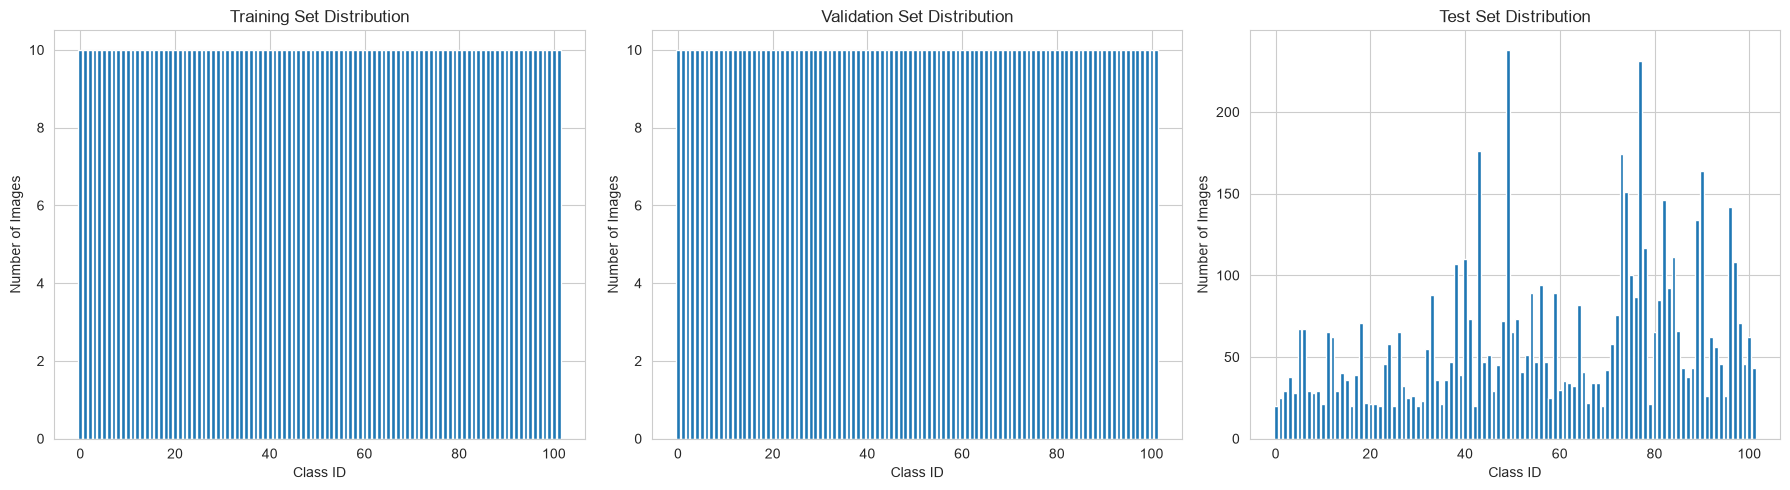

In [ ]:
# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(range(len(train_counts)), list(train_counts.values()))
axes[0].set_title('Training Set Distribution')
axes[0].set_xlabel('Class ID')
axes[0].set_ylabel('Number of Images')

axes[1].bar(range(len(val_counts)), list(val_counts.values()))
axes[1].set_title('Validation Set Distribution')
axes[1].set_xlabel('Class ID')
axes[1].set_ylabel('Number of Images')

axes[2].bar(range(len(test_counts)), list(test_counts.values()))
axes[2].set_title('Test Set Distribution')
axes[2].set_xlabel('Class ID')
axes[2].set_ylabel('Number of Images')

plt.tight_layout()
plt.show()

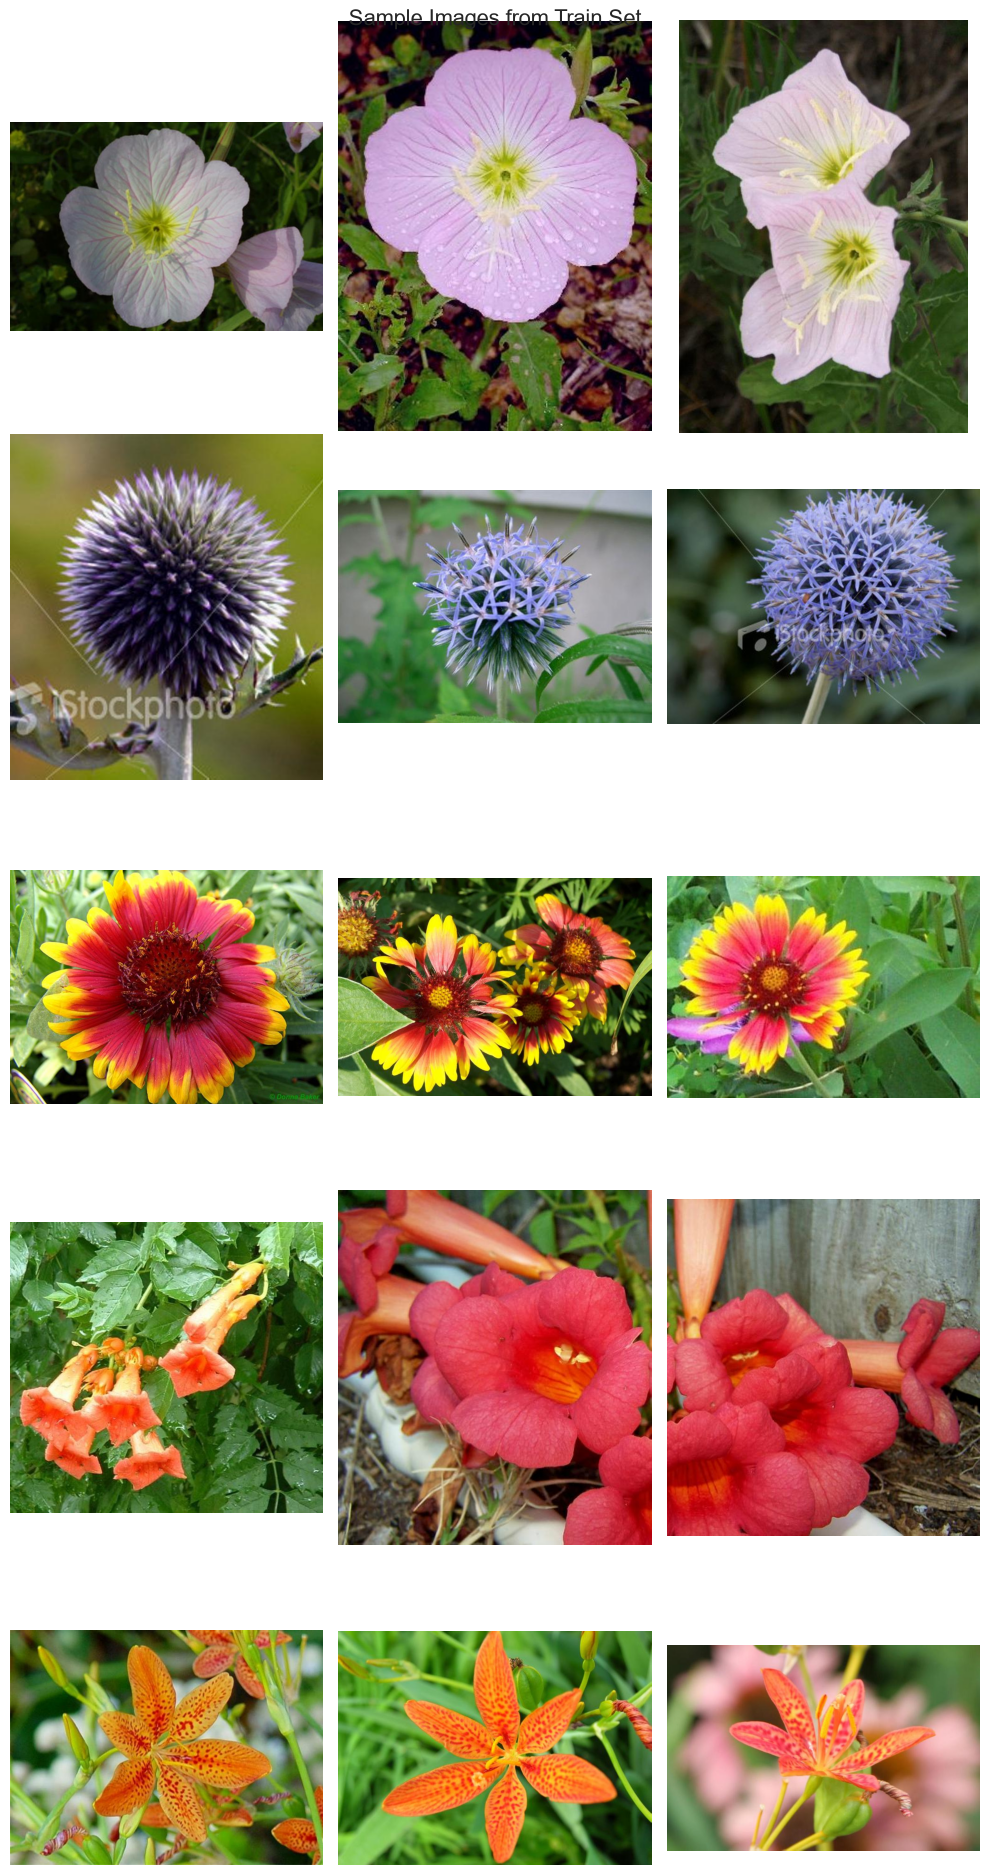

In [ ]:
# Display sample images from different classes
def display_sample_images(split='train', num_classes=6, images_per_class=2):
    split_dir = DATA_DIR / split
    class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])[:num_classes]
    
    fig, axes = plt.subplots(num_classes, images_per_class, figsize=(10, 20))
    
    for i, class_dir in enumerate(class_dirs):
        images = list(class_dir.glob('*.jpg'))[:images_per_class]
        for j, img_path in enumerate(images):
            img = Image.open(img_path)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_ylabel(f'Class {class_dir.name}', fontsize=10)
    
    plt.suptitle(f'Sample Images from {split.capitalize()} Set', fontsize=16)
    plt.tight_layout()
    plt.show()

display_sample_images('train', num_classes=5, images_per_class=3)

Image Size Statistics:
       width height
count      0      0
unique     0      0
top      NaN    NaN
freq     NaN    NaN


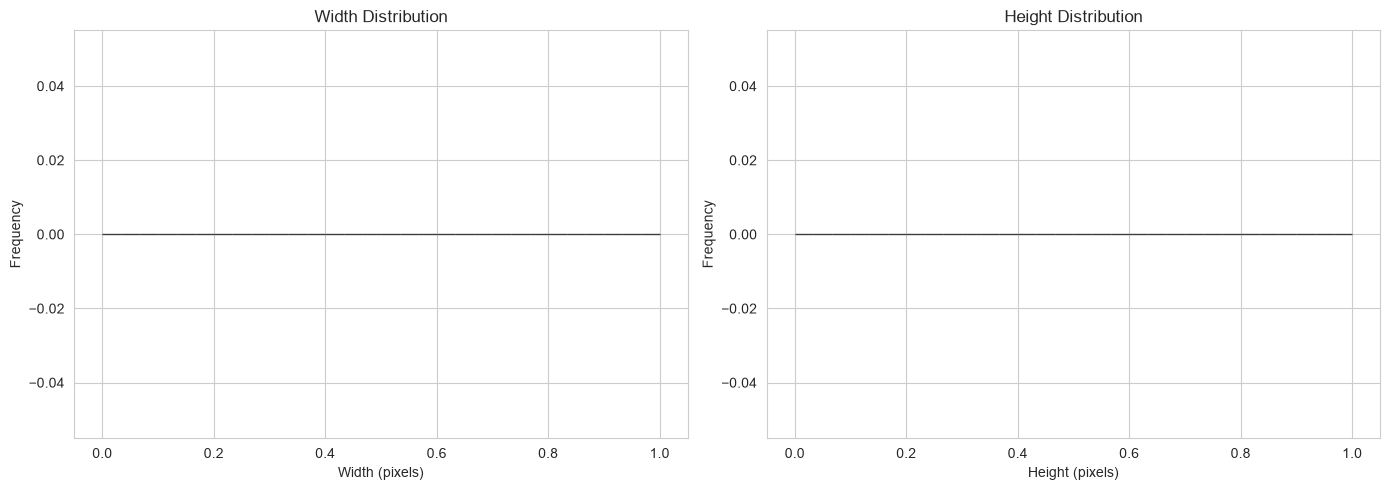

In [ ]:
# Analyze image sizes
def analyze_image_sizes(split='train', sample_size=100):
    split_dir = DATA_DIR / split
    sizes = []
    
    for class_dir in split_dir.iterdir():
        if class_dir.is_dir():
            for img_path in list(class_dir.glob('*.jpg'))[:sample_size//len(list(split_dir.iterdir()))]:
                with Image.open(img_path) as img:
                    sizes.append(img.size)
    
    sizes_df = pd.DataFrame(sizes, columns=['width', 'height'])
    print("Image Size Statistics:")
    print(sizes_df.describe())
    
    # Plot distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(sizes_df['width'], bins=30, alpha=0.7, edgecolor='black')
    axes[0].set_title('Width Distribution')
    axes[0].set_xlabel('Width (pixels)')
    axes[0].set_ylabel('Frequency')
    
    axes[1].hist(sizes_df['height'], bins=30, alpha=0.7, edgecolor='black')
    axes[1].set_title('Height Distribution')
    axes[1].set_xlabel('Height (pixels)')
    axes[1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    return sizes_df

sizes_df = analyze_image_sizes('train')

In [ ]:
# Check for corrupted images
def check_corrupted_images():
    corrupted = []
    for split in ['train', 'val', 'test']:
        split_dir = DATA_DIR / split
        for class_dir in split_dir.iterdir():
            if class_dir.is_dir():
                for img_path in class_dir.glob('*.jpg'):
                    try:
                        with Image.open(img_path) as img:
                            img.verify()
                    except Exception as e:
                        corrupted.append(str(img_path))
    
    if corrupted:
        print(f"Found {len(corrupted)} corrupted images:")
        for path in corrupted[:10]:
            print(f"  - {path}")
    else:
        print("No corrupted images found!")
    
    return corrupted

corrupted = check_corrupted_images()

No corrupted images found!


In [ ]:
# Summary statistics
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Dataset: Oxford 102 Flower Dataset")
print(f"Number of classes: 102")
print(f"Training images per class: 10 (total {sum(train_counts.values())})")
print(f"Validation images per class: 10 (total {sum(val_counts.values())})")
print(f"Test images per class: ~20+ (total {sum(test_counts.values())})")
print(f"\nImage sizes vary from {sizes_df['width'].min()}x{sizes_df['height'].min()} to {sizes_df['width'].max()}x{sizes_df['height'].max()}")
if sizes_df.empty:
    print("Average image size: unavailable (no image sizes found)")
else:
    avg_width = sizes_df['width'].mean()
    avg_height = sizes_df['height'].mean()
    print(f"Average image size: {int(avg_width)}x{int(avg_height)}")
print("=" * 50)

DATASET SUMMARY
Dataset: Oxford 102 Flower Dataset
Number of classes: 102
Training images per class: 10 (total 1020)
Validation images per class: 10 (total 1020)
Test images per class: ~20+ (total 6149)

Image sizes vary from nanxnan to nanxnan
Average image size: unavailable (no image sizes found)
